## EDA

In [ ]:
import numpy as np
import pandas as pd
import datetime
from datetime import datetime, timedelta

# import matplotlib
from matplotlib import pyplot
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import matplotlib.image as mpimg

# import seaborn
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option("display.max_rows", 50)
import warnings
warnings.filterwarnings('ignore')

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [7]:
# to be able to see multiple outputs from single cell
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

#### Import data

In [16]:
processed_df = pd.read_csv('../../data/processed/final_for_EDA/ttc_cleaned_final_with_peaktimes.csv')
code_description_df = pd.read_csv('../../data/raw/CodeDescriptions.csv')

In [17]:
processed_df.info()
processed_df

code_description_df.info()
code_description_df

<class 'pandas.DataFrame'>
RangeIndex: 20316 entries, 0 to 20315
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   year           20316 non-null  int64
 1   month          20316 non-null  str  
 2   date           20316 non-null  str  
 3   time           20316 non-null  str  
 4   day            20316 non-null  str  
 5   station        20316 non-null  str  
 6   code           20316 non-null  str  
 7   min_delay      20316 non-null  int64
 8   min_gap        20316 non-null  int64
 9   bound          20316 non-null  str  
 10  line           20316 non-null  str  
 11  vehicle        20316 non-null  int64
 12  time_hms       20316 non-null  str  
 13  time_category  20316 non-null  str  
 14  day_category   20316 non-null  str  
dtypes: int64(4), str(11)
memory usage: 2.3 MB


,year,month,date,time,day,station,code,min_delay,min_gap,bound,line,vehicle,time_hms,time_category,day_category
0,2025,March,2025-03-16,13:49,Sunday,old mill,PUTIJ,10,14,E,BD,5103,13:49:00,Mid_Day,Weekend
1,2025,January,2025-01-01,2:10,Wednesday,bathurst,MUSAN,5,9,E,BD,5227,02:10:00,Early_AM,Holiday
2,2025,February,2025-02-05,20:38,Wednesday,bathurst,SUDP,5,9,W,BD,5148,20:38:00,Evening,Weekday
3,2025,March,2025-03-21,11:40,Friday,bathurst,MUDD,5,9,W,BD,5170,11:40:00,Mid_Day,Weekday
4,2025,June,2025-06-11,15:32,Wednesday,bathurst,SUO,5,9,E,BD,5035,15:32:00,PM_Peak,Weekday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20311,2021,July,2021-07-02,22:20,Friday,yorkdale,SUDP,5,12,N,YU,5691,22:20:00,Late_Evening,Weekday
20312,2021,July,2021-07-27,18:04,Tuesday,yorkdale,TUO,5,8,S,YU,5431,18:04:00,PM_Peak,Weekday
20313,2021,August,2021-08-08,18:23,Sunday,yorkdale,MUO,5,10,S,YU,5856,18:23:00,PM_Peak,Weekend
20314,2026,January,2026-01-25,17:23,Sunday,yorkdale,PUTIS,5,10,N,YU,6056,17:23:00,PM_Peak,Weekend


<class 'pandas.DataFrame'>
RangeIndex: 140 entries, 0 to 139
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   _id          140 non-null    int64
 1   CODE         140 non-null    str  
 2   DESCRIPTION  140 non-null    str  
dtypes: int64(1), str(2)
memory usage: 3.4 KB


,_id,CODE,DESCRIPTION
0,1,EUAC,AIR CONDITIONING
1,2,EUAL,ALTERNATING CURRENT
2,3,EUATC,ATC RC&S EQUIPMENT
3,4,EUBK,BRAKES
4,5,EUBO,BODY
...,...,...,...
135,136,TUSC,OPERATOR OVERSPEED
136,137,TUSET,CONTROLS IMPROPERLY BLOWN DOWN
137,138,TUST,STORM TRAINS
138,139,TUSUP,SUPERVISORY ERROR


### Basic Overview of Processed_df

In [19]:
processed_df.shape

(20316, 15)

In [21]:
processed_df.describe()
processed_df.describe(include='object')

,year,min_delay,min_gap,vehicle
count,20316.000000,20316.00000,20316.000000,20316.000000
mean,2023.539673,11.43990,14.840815,5492.906773
std,1.222583,22.54048,20.690960,755.481247
min,2021.000000,5.00000,0.000000,0.000000
25%,2023.000000,5.00000,10.000000,5243.000000
50%,2024.000000,7.00000,11.000000,5551.500000
75%,2025.000000,11.00000,15.000000,5876.000000
max,2026.000000,900.00000,906.000000,9546.000000


,month,date,time,day,station,code,bound,line,time_hms,time_category,day_category
count,20316,20316,20316,20316,20316,20316,20316,20316,20316,20316,20316
unique,12,1710,1305,7,71,121,5,3,1305,6,3
top,January,2026-01-25,5:59,Thursday,bloor,SUDP,S,YU,05:59:00,Mid_Day,Weekday
freq,2392,38,99,3073,970,2739,6235,12192,99,4887,14824


### Delay Distribution Analysis

<Axes: xlabel='min_delay', ylabel='Count'>

Text(0.5, 1.0, 'Distribution of Delay Minutes')

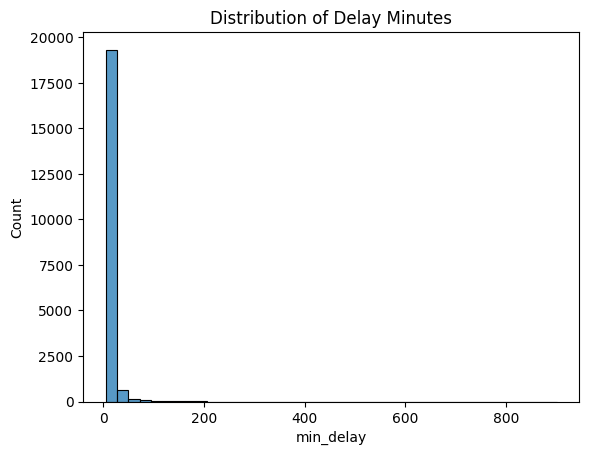

In [22]:
sns.histplot(processed_df["min_delay"], bins=40)
plt.title("Distribution of Delay Minutes")
plt.show()

In [24]:
# Check Outliers
processed_df["min_delay"].quantile([0.5, 0.75, 0.9, 0.95, 0.99])

0.50     7.0
0.75    11.0
0.90    19.0
0.95    27.0
0.99    75.0
Name: min_delay, dtype: float64

### Delay by Time Category (Peak Analysis)

In [31]:
processed_df["min_delay"].max()
processed_df.groupby("time_category")["min_delay"].mean().sort_values(ascending=False)
processed_df.groupby("time_category")["min_delay"].median()

np.int64(900)

time_category
PM_Peak         11.978200
Mid_Day         11.950685
Evening         11.331479
Early_AM        11.280193
AM_Peak         10.773227
Late_Evening    10.504167
Name: min_delay, dtype: float64

time_category
AM_Peak         6.0
Early_AM        7.0
Evening         7.0
Late_Evening    7.0
Mid_Day         7.0
PM_Peak         7.0
Name: min_delay, dtype: float64

In [32]:
# typical operational delay without extreme disruption noise
processed_df[processed_df["min_delay"] < 30] \
    .groupby("time_category")["min_delay"] \
    .mean()

time_category
AM_Peak         8.046207
Early_AM        8.757148
Evening         8.944998
Late_Evening    9.015348
Mid_Day         8.746941
PM_Peak         9.101600
Name: min_delay, dtype: float64

<Axes: xlabel='time_category', ylabel='min_delay'>

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Early_AM'),
  Text(1, 0, 'AM_Peak'),
  Text(2, 0, 'Mid_Day'),
  Text(3, 0, 'PM_Peak'),
  Text(4, 0, 'Evening'),
  Text(5, 0, 'Late_Evening')])

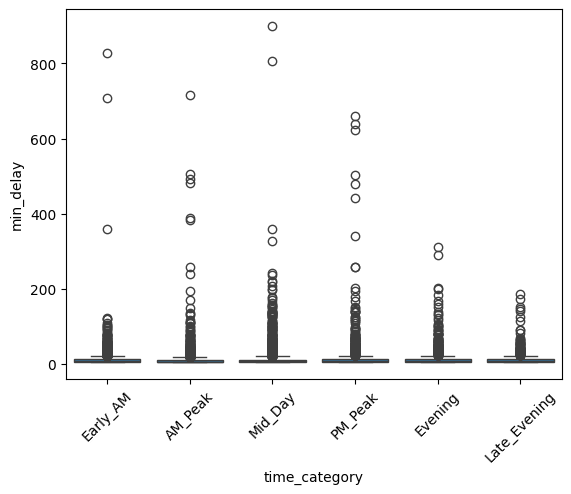

In [29]:
order = [
    "Early_AM",
    "AM_Peak",
    "Mid_Day",
    "PM_Peak",
    "Evening",
    "Late_Evening"
]

sns.boxplot(
    data=processed_df, 
    x="time_category", 
    y="min_delay",
    order=order)

plt.xticks(rotation=45)
plt.show()

<Axes: xlabel='time_category', ylabel='min_delay'>

(0.0, 40.0)

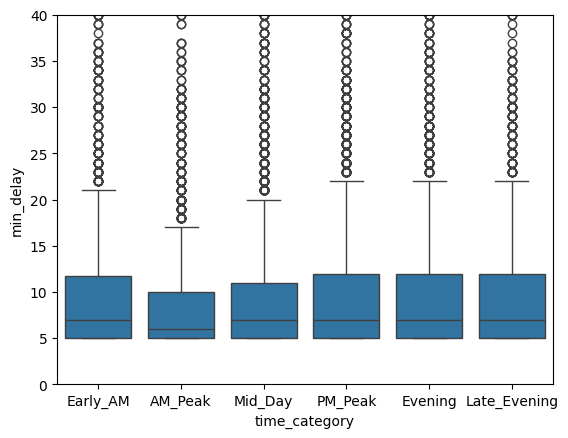

In [34]:
sns.boxplot(data=processed_df, x="time_category", y="min_delay", order=order)
plt.ylim(0, 40)
plt.show()

### Delay by Day Type (Weekend, Weekday & Holiday)

In [35]:
processed_df.groupby("day_category")["min_delay"].agg(["mean","median","count"])

,mean,median,count
day_category,,,
Holiday,8.617544,6.0,285
Weekday,11.422558,7.0,14824
Weekend,11.643749,7.0,5207


<Axes: xlabel='day_category', ylabel='min_delay'>

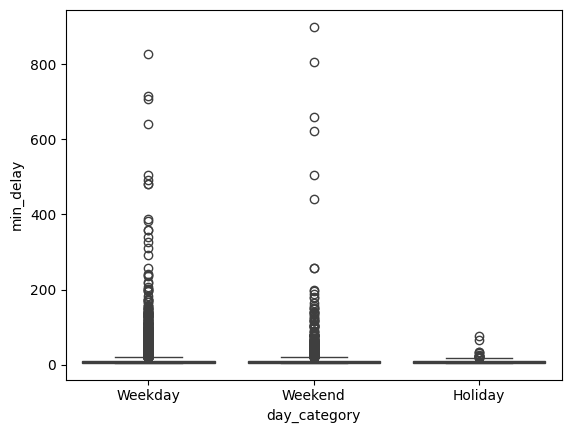

In [37]:
order2 = [
    "Weekday",
    "Weekend",
    "Holiday"
]
sns.boxplot(data=processed_df, x="day_category", y="min_delay", order=order2)
plt.show()

<Axes: xlabel='day_category', ylabel='min_delay'>

(0.0, 40.0)

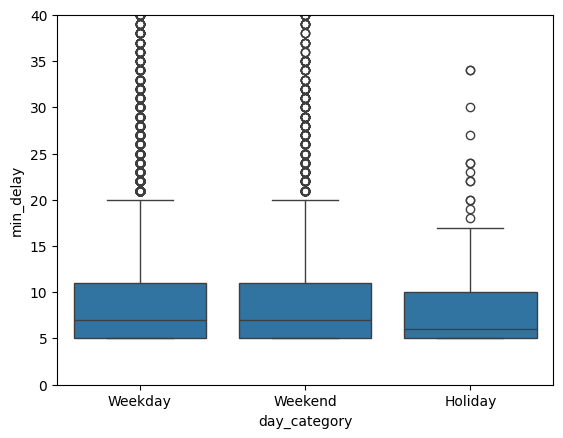

In [38]:
sns.boxplot(data=processed_df, x="day_category", y="min_delay", order=order2)
plt.ylim(0, 40)
plt.show()

### Top Problem Codes

In [39]:
processed_df.groupby("code")["min_delay"].agg(["mean","count"]).sort_values("mean", ascending=False).head(15)

,mean,count
code,,
MUFM,291.000000,1
PUTTP,151.833333,6
PUTS,101.666667,6
PUTIS,100.444444,54
MUEC,86.000000,4
MUPR1,84.007353,136
PUSTP,48.571429,7
PUTSM,47.590909,22
SUBT,39.263158,38


In [43]:
code_description_df = code_description_df.rename({"CODE":"code", "DESCRIPTION":"description"}, axis=1)
code_description_df

,_id,code,description
0,1,EUAC,AIR CONDITIONING
1,2,EUAL,ALTERNATING CURRENT
2,3,EUATC,ATC RC&S EQUIPMENT
3,4,EUBK,BRAKES
4,5,EUBO,BODY
...,...,...,...
135,136,TUSC,OPERATOR OVERSPEED
136,137,TUSET,CONTROLS IMPROPERLY BLOWN DOWN
137,138,TUST,STORM TRAINS
138,139,TUSUP,SUPERVISORY ERROR


In [44]:
pd.set_option("display.max_rows", None)
code_summary = processed_df.groupby("code")["min_delay"].agg(["mean","count"])
code_summary_df = code_summary[code_summary["count"] > 50].sort_values("mean", ascending=False).reset_index()
code_summary_df_rev = pd.merge(code_summary_df, code_description_df[["code","description"]], on="code", how="left")
code_summary_df_rev
pd.set_option("display.max_rows", 50)

,code,mean,count,description
0,PUTIS,100.444444,54,ICE/SNOW RELATED PROBLEM
1,MUPR1,84.007353,136,PRIORITY ONE â TRAIN IN CONTACT WITH PERSON
2,MUPLB,36.304762,210,FIRE/SMOKE PLAN B â SOURCE TTC (TRACK LEVEL)
3,PUSSW,33.256881,109,TRACK SWITCH FAILURE â S/E/C RELATED PROBLEM
4,MUWEA,30.962963,108,WEATHER REPORTS / RELATED PROBLEMS
5,EUVE,17.604396,91,WORK VEHICLE
6,PUSI,17.603448,58,SIGNAL OR RELATED COMPONENTS FAILURE
7,PUTDN,15.857143,84,DEBRIS AT TRACK LEVEL â NON-CONTROLLABLE
8,SUPOL,15.737931,145,HELD BY POLICE â NON TTC RELATED
9,EUCD,15.527473,91,RC&S CONSEQUENTIAL DELAY (SECOND DELAY SAME FA...


### Station-Level Impact

In [45]:
station_delay = processed_df.groupby("station")["min_delay"].mean().sort_values(ascending=False)
station_delay.head(20)

station
woodbine         20.422535
islington        18.971292
jane             18.194030
sheppard west    15.380822
old mill         15.314961
victoria park    15.065831
broadview        14.880658
runnymede        14.782609
dufferin         14.244275
cedarvale        14.166667
yorkdale         13.813620
castle frank     13.807229
warden           13.802632
lansdowne        13.669065
museum           13.528846
glencairn        13.240506
sherbourne       12.721591
st patrick       12.687075
high park        12.576923
main street      12.534759
Name: min_delay, dtype: float64

<Figure size 800x600 with 0 Axes>

<Axes: xlabel='min_delay', ylabel='station'>

Text(0.5, 1.0, 'Top 15 Stations by Average Delay')

Text(0.5, 0, 'Average Delay (minutes)')

Text(0, 0.5, 'Station')

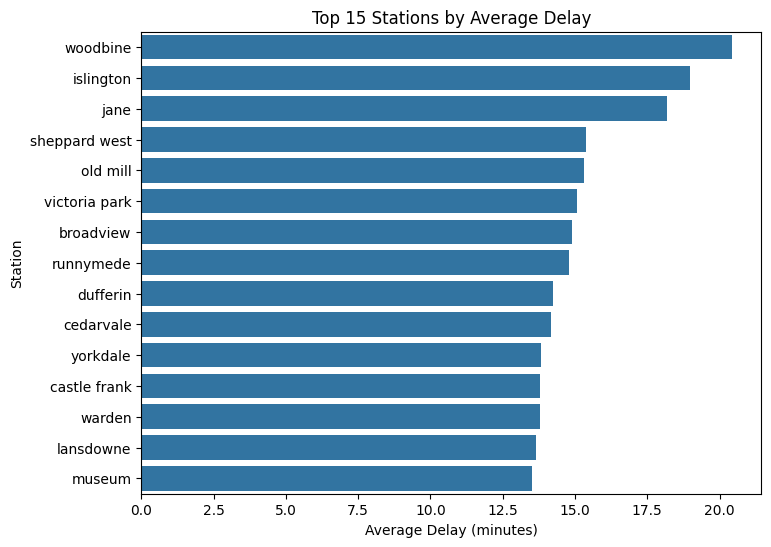

In [49]:
top15 = station_delay.head(15).reset_index()

plt.figure(figsize=(8,6))
sns.barplot(data=top15, x="min_delay", y="station")
plt.title("Top 15 Stations by Average Delay")
plt.xlabel("Average Delay (minutes)")
plt.ylabel("Station")
plt.show()

### Line-Level Comparison

In [50]:
processed_df.groupby("line")["min_delay"].mean()

line
BD     12.528978
SHP    11.151776
YU     10.819144
Name: min_delay, dtype: float64

### Time Trend - Monthly Trend

In [51]:
processed_df["date"] = pd.to_datetime(processed_df["date"])

<Figure size 1800x800 with 0 Axes>

(array([18567., 18597., 18628., 18659., 18687., 18718., 18748., 18779.,
        18809., 18840., 18871., 18901., 18932., 18962., 18993., 19024.,
        19052., 19083., 19113., 19144., 19174., 19205., 19236., 19266.,
        19297., 19327., 19358., 19389., 19417., 19448., 19478., 19509.,
        19539., 19570., 19601., 19631., 19662., 19692., 19723., 19754.,
        19783., 19814., 19844., 19875., 19905., 19936., 19967., 19997.,
        20028., 20058., 20089., 20120., 20148., 20179., 20209., 20240.,
        20270., 20301., 20332., 20362., 20393., 20423., 20454., 20485.,
        20513., 20544., 20574.]),
 [Text(18567.0, 0, '2020-11'),
  Text(18597.0, 0, '2020-12'),
  Text(18628.0, 0, '2021-01'),
  Text(18659.0, 0, '2021-02'),
  Text(18687.0, 0, '2021-03'),
  Text(18718.0, 0, '2021-04'),
  Text(18748.0, 0, '2021-05'),
  Text(18779.0, 0, '2021-06'),
  Text(18809.0, 0, '2021-07'),
  Text(18840.0, 0, '2021-08'),
  Text(18871.0, 0, '2021-09'),
  Text(18901.0, 0, '2021-10'),
  Text(18932.0, 0,

Text(0.5, 1.0, 'Monthly Average Delay Trend')

Text(0.5, 0, 'Month')

Text(0, 0.5, 'Average Delay (minutes)')

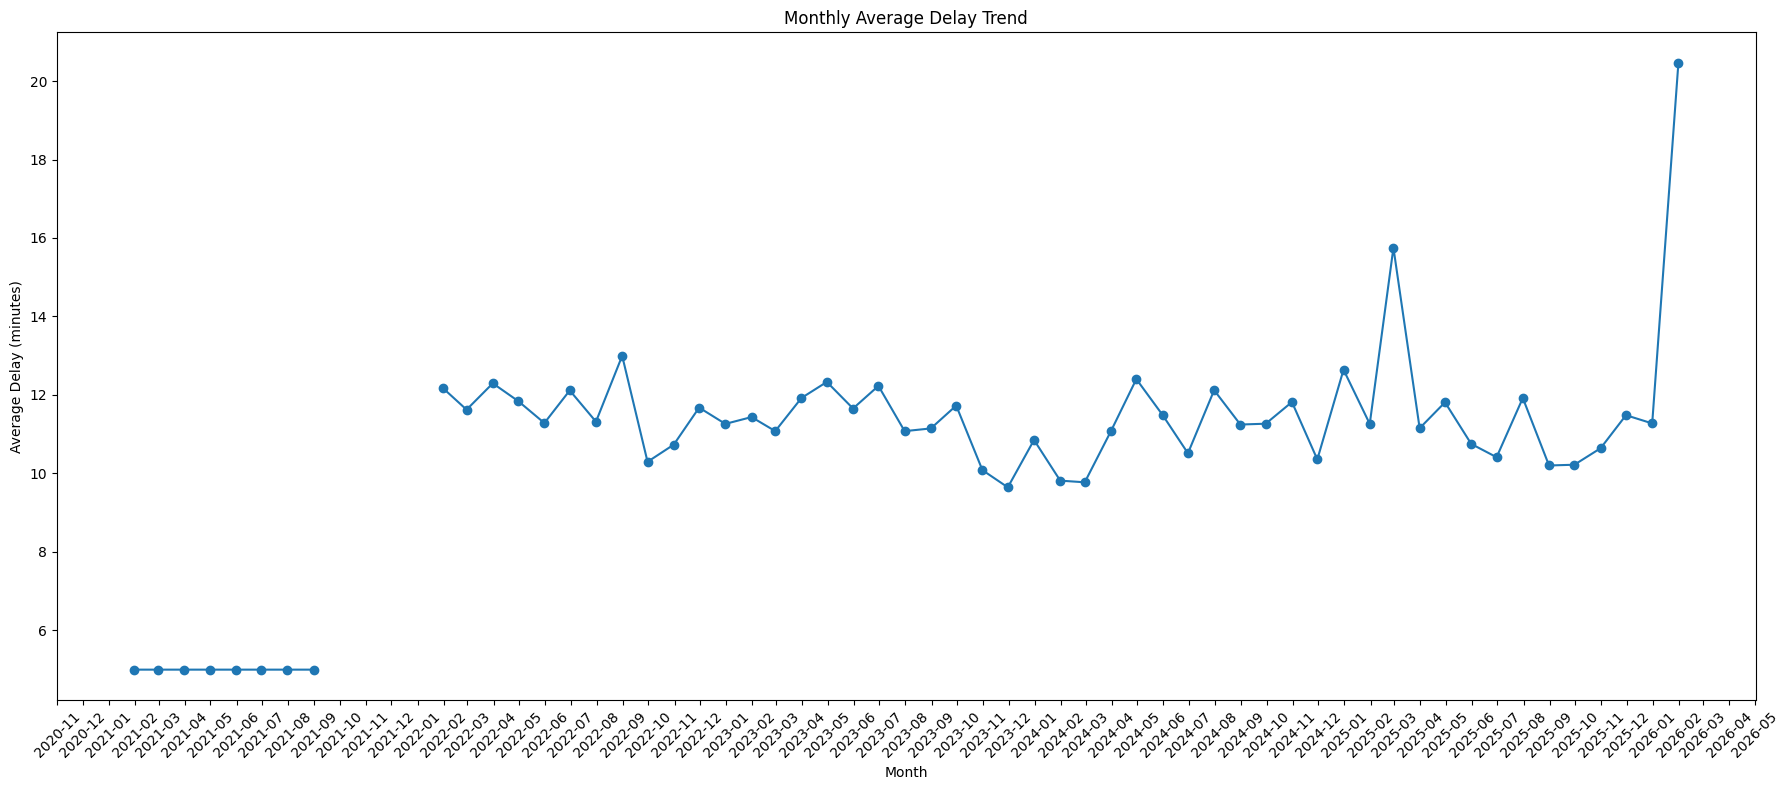

In [58]:
import matplotlib.dates as mdates

# Ensure datetime
processed_df["date"] = pd.to_datetime(processed_df["date"])

# Monthly aggregation
monthly_delay = (
    processed_df
    .groupby(pd.Grouper(key="date", freq="ME"))["min_delay"]
    .mean()
)

# Plot
plt.figure(figsize=(18,8))  # wider graph

plt.plot(monthly_delay.index, monthly_delay.values, marker="o")

# Force every month on x-axis
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.xticks(rotation=45)
plt.title("Monthly Average Delay Trend")
plt.xlabel("Month")
plt.ylabel("Average Delay (minutes)")

plt.tight_layout()
plt.show()

### Peak and Day Type Interpretation

<Axes: xlabel='day_category', ylabel='time_category'>

Text(0.5, 1.0, 'Average Delay Heatmap')

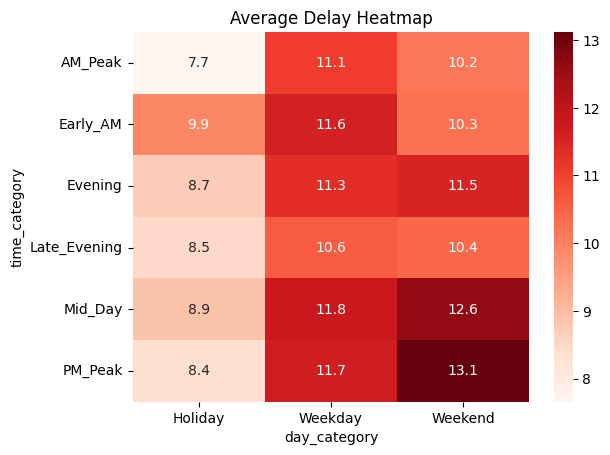

In [59]:
pivot = processed_df.pivot_table(
    values="min_delay",
    index="time_category",
    columns="day_category",
    aggfunc="mean"
)

sns.heatmap(pivot, annot=True, fmt=".1f", cmap="Reds")
plt.title("Average Delay Heatmap")
plt.show()

### Correlation Between Delay and Gap

In [60]:
processed_df[["min_delay","min_gap"]].corr()

,min_delay,min_gap
min_delay,1.000000,0.880848
min_gap,0.880848,1.000000


<Axes: xlabel='min_gap', ylabel='min_delay'>

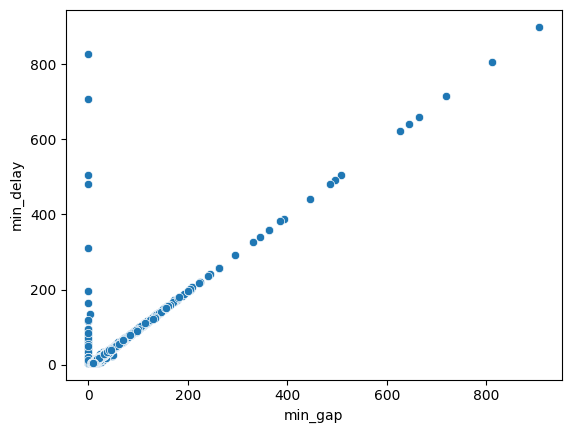

In [61]:
sns.scatterplot(data=processed_df, x="min_gap", y="min_delay")
plt.show()

### Extreme Events

In [62]:
processed_df[processed_df["min_delay"] > 30].groupby("code").size().sort_values(ascending=False)

code
SUUT     124
MUPR1    104
MUPLB     74
SUO       47
SUDP      40
        ... 
MUFS       1
MUNOA      1
PUTCD      1
TUNOA      1
TUOS       1
Length: 72, dtype: int64

### Other Analysis

In [63]:
processed_df.groupby("vehicle")["min_delay"].mean().sort_values(ascending=False).head(10)

vehicle
6000    606.500000
5375    340.000000
5034     48.500000
3134     46.000000
5763     39.000000
5239     38.259259
5044     36.866667
5354     35.125000
5289     34.633333
5201     34.000000
Name: min_delay, dtype: float64

In [64]:
processed_df.groupby("bound")["min_delay"].mean()

bound
B    10.000000
E    12.383659
N    11.345176
S    10.301524
W    12.378372
Name: min_delay, dtype: float64

In [18]:
pd.set_option("display.max_rows", None)
processed_df["code"].value_counts(dropna=False)
pd.set_option("display.max_rows", 50)

code
SUDP     2739
PUOPO    1460
SUUT     1305
MUIR     1274
SUO      1254
MUI      1032
MUPAA     790
MUSAN     685
MUATC     653
TUO       609
SUAP      537
MUO       453
EUDO      420
SUEAS     402
PUTWZ     396
MUDD      377
TUMVS     272
MUTO      267
EUNT      252
SUG       220
TUNIP     212
MUPLB     210
TUNOA     207
PUTR      204
PUTO      178
MUD       156
SUPOL     145
TUCC      137
MUPR1     136
PUSAC     126
EUBK      125
SUAE      121
TUS       117
EUO       109
PUSSW     109
MUWEA     108
EUCD       91
EUVE       91
TUATC      87
PUSTS      86
PUTDN      84
TUOS       83
PUSRA      82
TUSUP      76
EUME       75
MUIS       73
EUBO       70
MUSC       65
MUNOA      64
EUYRD      59
PUSI       58
MUCL       57
EUPI       56
PUSCR      55
PUSO       54
PUTIS      54
TUSC       50
MUIRS      49
EUSC       42
MUTD       38
SUBT       38
SUROB      35
MUWR       33
PUSTC      32
PUSIS      31
EUATC      30
PUTIJ      27
PUTD       27
EUAC       27
EUTRD      26
PUATC      26
E